##### ***AlexNet 卷积神经网络***
###### 在LeNet提出后，虽然卷积神经网络因此在计算机视觉领域和机器学习领域变得出名，但它只在小批量数据上表现出了优势，对于更大，更真实的数据集上是否可行还有待研究。而当时的主流方法仍是机器学习领域的方法，如支持向量机(SVM)和随机森林(Random Forest)等。
###### 在计算机视觉中，神经网络往往会直接输入原始的像素点或者只经过简单的预处理。但在传统机器学习方法中，如SVM和随机森林等，通常需要手动提取特征，这往往需要领域知识和经验。这吸引了当时大批的学者撰写特征提取算法，然而另一批学者则认为特征本身也应该被学习。于是在2012年ImageNet挑战赛中AlexNet横空出世提出了一种新的卷积神经网络变体。
##### ***AlexNet 架构***
###### 相比于LeNet，其实AlexNet并没有太多的改变，只是在LeNet的基础上加了更多的层和参数，而且使用ReLU作为激活函数，而不是LeNet中的sigmoid函数。还加入了Dropout层来防止过拟合。
###### 具体架构如下：输入一个3x224x224的RGB图像，通过一个卷积层，卷积核的大小是11x11，输出通道为96，padding=2，stride=4，输出((224+2x2-11)/4+1)55x55的特征图，接着通过一个最大池化层，窗口大小是3x3，步幅是2，将特征图缩小到((55-3)/2+1)27x27，而后再进行卷积核为5x5的卷积，输出通道为256，padding=2，stride=1，输出((27+2x2-5)/1+1)27x27的特征图，接着再进行最大池化层(3x3,stride=2)，将其进一步缩小到13x13，接着进行两次卷积核为3x3的卷积，输出通道为384，padding=1，然后进行一次卷积核为3x3的卷积，输出通道为256，padding=1，后进行一次最大池化层，窗口是3x3，stride=2，得到256x6x6。最后将256x6x6的特征图展平为9216维向量分别进行4096，4096的全连接层，最后使用softmax得到1000分类。
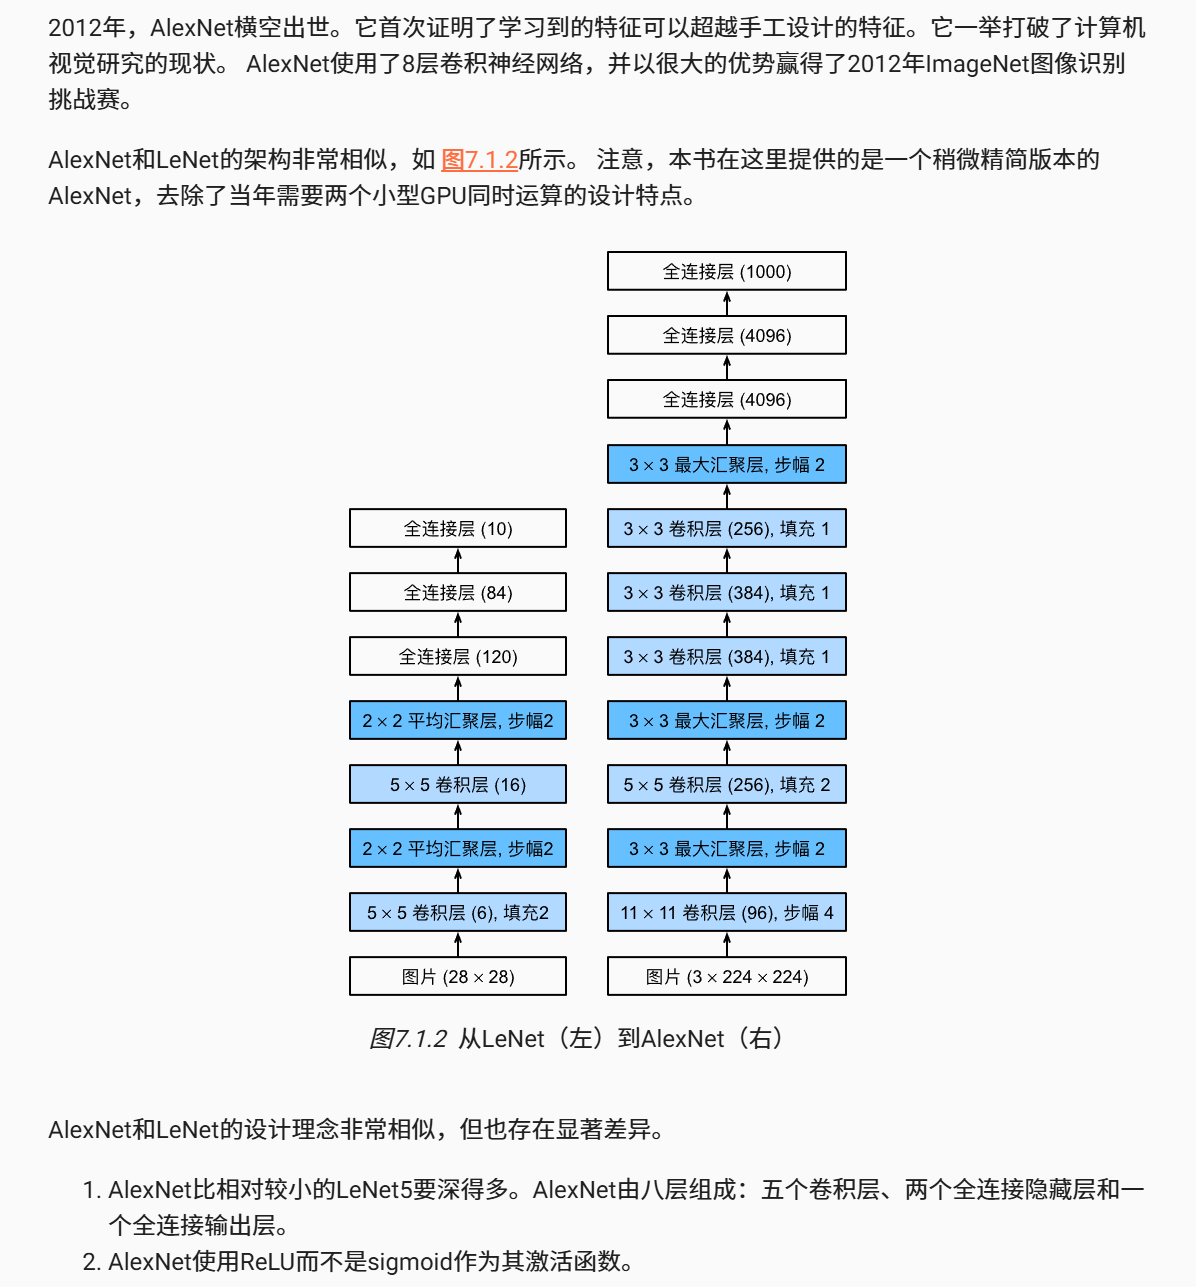

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 96, 11, 4, 1),
    nn.ReLU(),
    nn.MaxPool2d(3, 2),
    nn.Conv2d(96, 256, 5, 1, 2),
    nn.ReLU(),
    nn.MaxPool2d(3, 2),
    nn.Conv2d(256, 384, 1, 1),
    nn.ReLU(),
    nn.Conv2d(384, 384, 1, 1),
    nn.ReLU(),
    nn.Conv2d(384, 256, 1, 1),
    nn.ReLU(),
    nn.MaxPool2d(3, 2),
    nn.Flatten(),
    # 由于开始的第一层的padding=1，所以这里的输入是6400
    nn.Linear(6400, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    # 这里使用了Fashion-MNIST数据集，所以输出类别为10
    nn.Linear(4096, 10)
)


In [ ]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

In [3]:
# 读取数据集
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize = 224)

KeyboardInterrupt: 

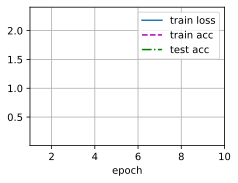

In [6]:
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

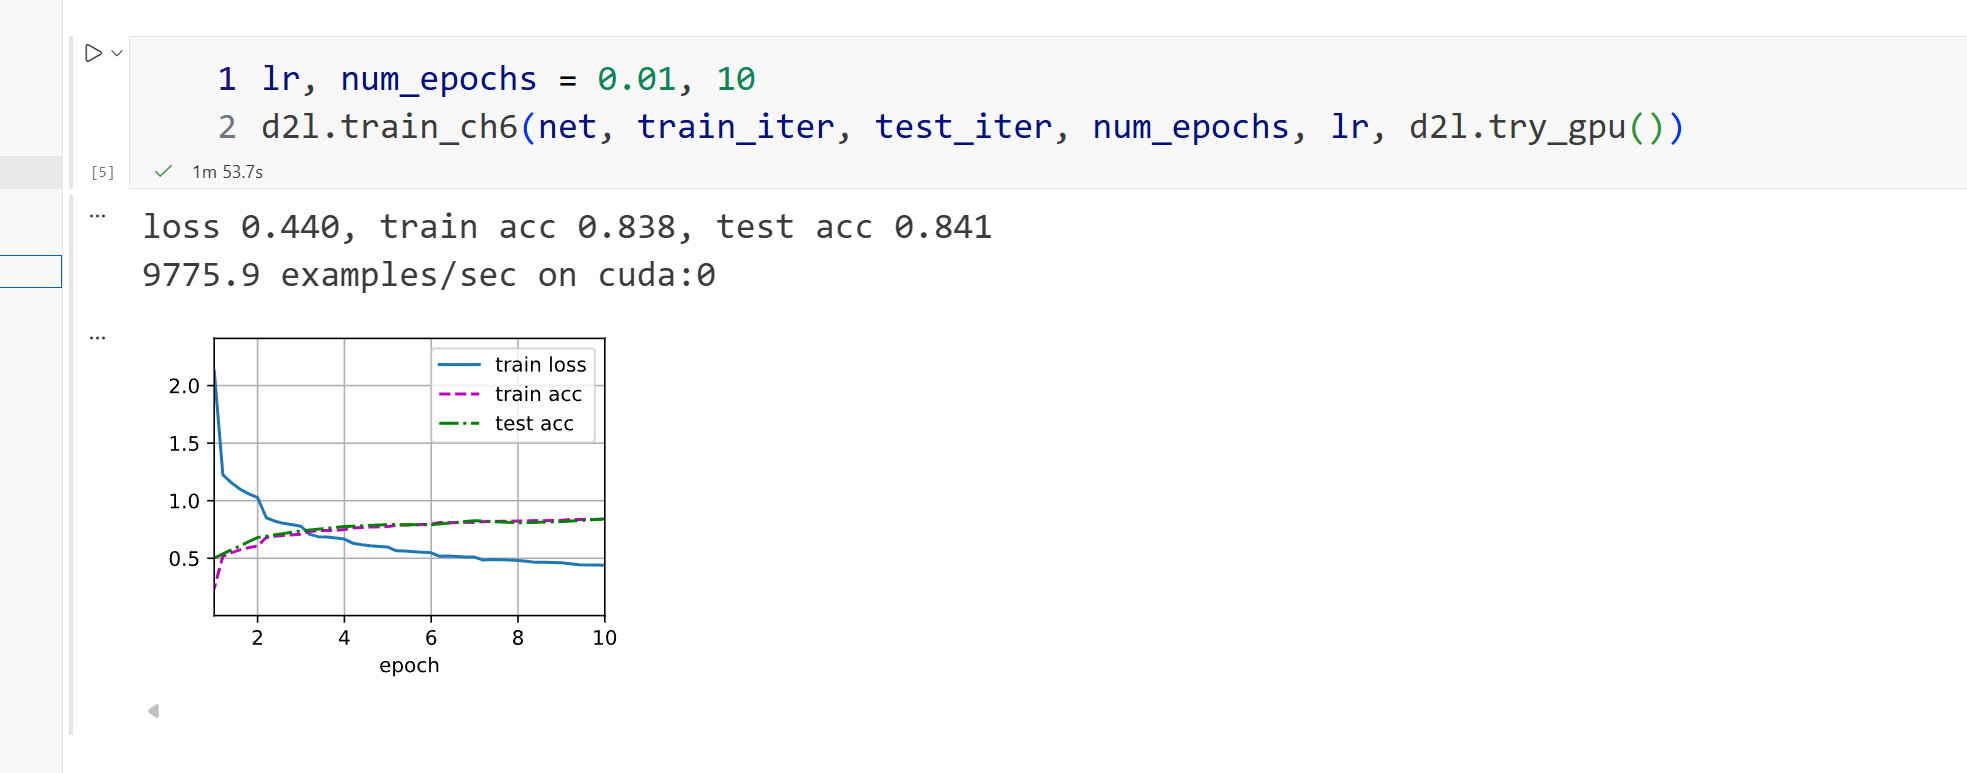